In [23]:
# --------------------------------------------------------------
# Setup: libraries, file paths, output folder
# --------------------------------------------------------------
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA = Path("data")  # change if needed
CUSTOMERS_FILE = DATA / "churn_customers_95k_dirty.csv"
INTERVIEWS_FILE = DATA / "churn_exit_interviews_3500_dirty.csv"
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

print("Customer file found:", CUSTOMERS_FILE.exists())
print("Interview file found:", INTERVIEWS_FILE.exists())

Customer file found: True
Interview file found: True


In [24]:
# --------------------------------------------------------------
# Inspect raw files before cleaning
# --------------------------------------------------------------
cust_raw = pd.read_csv(CUSTOMERS_FILE)
iv_raw = pd.read_csv(INTERVIEWS_FILE)

print("CUSTOMERS", cust_raw.shape)
print(cust_raw.isna().sum())
print("duplicate rows", int(cust_raw.duplicated().sum()))
print("duplicate IDs", int(cust_raw["Customer_ID"].duplicated().sum()))
print("\nChurn raw labels:\n", cust_raw["Churn_Flag"].value_counts(dropna=False))
print("\nINTERVIEWS", iv_raw.shape)
print(iv_raw.isna().sum())
print("interview duplicate rows", int(iv_raw.duplicated().sum()))
cust_raw.head(2)

CUSTOMERS (95380, 10)
Customer_ID            0
Age                    0
Gender               342
Region               229
Tenure_Months          0
Subscription_Type    239
Monthly_Spend          0
Support_Tickets        0
Churn_Flag           586
Signup_Date            0
dtype: int64
duplicate rows 320
duplicate IDs 380

Churn raw labels:
 Churn_Flag
0      69788
1      14148
Yes     5665
No      5193
NaN      586
Name: count, dtype: int64

INTERVIEWS (3605, 3)
Customer_ID          0
Churn_Flag          21
Exit_Reason_Text    73
dtype: int64
interview duplicate rows 59


,Customer_ID,Age,Gender,Region,Tenure_Months,Subscription_Type,Monthly_Spend,Support_Tickets,Churn_Flag,Signup_Date
0,C000001,18,Female,South,9,mid,34.02,1,0,17-02-2024
1,C000002,18,M,Central,60,BASIC,6.96,2,0,05-01-2023


In [25]:
# -----------------------------------------------------------------------
# Clean customer table (IDs, types, ranges). Do not fill Churn_Flag.
# -----------------------------------------------------------------------

def clean_id(x):
    s = str(x).strip().upper().replace(" ", "")
    if s.startswith("XC"):
        s = "C" + s[2:]
    m = re.match(r"C(\d+)$", s)
    return "C" + m.group(1).zfill(6) if m else s

def clean_gender(x):
    s = re.sub(r"[^a-z]", "", str(x).lower())
    if s in {"m", "male"}: return "Male"
    if s in {"f", "fem", "female"}: return "Female"
    if s in {"nb", "nonbinary"}: return "Non-binary"
    if "prefer" in s: return "Prefer not to say"
    return "Unknown"

def clean_region(x):
    s = re.sub(r"[^a-z]", "", str(x).lower())
    return {
        "north": "North", "nrt": "North",
        "south": "South", "sth": "South",
        "east": "East", "est": "East",
        "west": "West", "wst": "West",
        "central": "Central", "ctr": "Central",
    }.get(s, "Unknown")

def clean_plan(x):
    s = re.sub(r"[^a-z]", "", str(x).lower())
    if s in {"basic", "entry", "starter"}: return "Basic"
    if s in {"standard", "std", "mid", "pro"}: return "Standard"
    if s in {"premium", "prm", "gold"}: return "Premium"
    if s in {"enterprise", "ent", "corp", "corporate"}: return "Enterprise"
    return "Unknown"

def clean_churn(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"1", "yes", "y", "true"}: return 1
    if s in {"0", "no", "n", "false"}: return 0
    return np.nan

def parse_date(series):
    s = series.astype(str).str.replace(r"\s+00:00$", "", regex=True)
    d1 = pd.to_datetime(s, format="%d-%m-%Y", errors="coerce")
    d2 = pd.to_datetime(s, format="%m-%d-%Y", errors="coerce")
    return d1.fillna(d2)

# ---- apply ----
cust = cust_raw.copy()
print("START", len(cust))

n = int(cust.duplicated().sum())
cust = cust.drop_duplicates()
print("removed duplicate rows:", n)

cust["Customer_ID"] = cust["Customer_ID"].map(clean_id)
n = int(cust["Customer_ID"].duplicated().sum())
cust = cust.drop_duplicates("Customer_ID", keep="first")
print("removed extra ID collisions:", n)

cust["Age"] = pd.to_numeric(cust["Age"], errors="coerce")
bad_age = (cust["Age"] < 18) | (cust["Age"] > 80)
print("invalid ages set to median:", int(bad_age.sum()))
cust.loc[bad_age, "Age"] = np.nan
cust["Age"] = cust["Age"].fillna(cust["Age"].median())

ten = pd.to_numeric(cust["Tenure_Months"], errors="coerce")
print("negative tenure flipped:", int((ten < 0).sum()), "| tenure > 120 capped:", int((ten.abs() > 120).sum()))
cust["Tenure_Months"] = ten.abs().clip(0, 120)

tix = pd.to_numeric(cust["Support_Tickets"], errors="coerce")
print("negative tickets set to 0:", int((tix < 0).sum()))
cust["Support_Tickets"] = tix.clip(lower=0).fillna(0).astype(int)

spend = cust["Monthly_Spend"].astype(str).str.replace("₹", "", regex=False).str.replace(",", "", regex=False)
cust["Monthly_Spend"] = pd.to_numeric(spend, errors="coerce")
cust["Monthly_Spend"] = cust["Monthly_Spend"].fillna(cust["Monthly_Spend"].median())
cust["Annual_Spend"] = cust["Monthly_Spend"] * 12

cust["Gender"] = cust["Gender"].map(clean_gender)
cust["Region"] = cust["Region"].map(clean_region)
cust["Subscription_Type"] = cust["Subscription_Type"].map(clean_plan)
cust["Churn_Flag"] = cust["Churn_Flag"].map(clean_churn)
print("churn values left missing (NOT filled):", int(cust["Churn_Flag"].isna().sum()))

cust["Signup_Date"] = parse_date(cust["Signup_Date"])
cust["Signup_Year"] = cust["Signup_Date"].dt.year
cust["Tenure_Group"] = pd.cut(cust["Tenure_Months"], [-0.1, 6, 12, 24, 60, 120],
                              labels=["0-6 mo", "6-12 mo", "1-2 yr", "2-5 yr", "5-10 yr"])
cust["Spend_Group"] = pd.qcut(cust["Monthly_Spend"], 4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])

print("CLEAN customers", cust.shape)

START 95380
removed duplicate rows: 320
removed extra ID collisions: 60
invalid ages set to median: 474
negative tenure flipped: 190 | tenure > 120 capped: 190
negative tickets set to 0: 99
churn values left missing (NOT filled): 581
CLEAN customers (95000, 14)


In [26]:
# -----------------------------------------------------------
# Baseline KPIs: valid accounts, churn rate, ARR at risk
# -----------------------------------------------------------
valid = cust.dropna(subset=["Churn_Flag"]).copy()
valid["Churn_Flag"] = valid["Churn_Flag"].astype(int)

N = len(valid)
LEFT = int(valid["Churn_Flag"].sum())
RATE = valid["Churn_Flag"].mean()
ARR = valid["Annual_Spend"].sum()
LOST = valid.loc[valid["Churn_Flag"] == 1, "Annual_Spend"].sum()

print(f"Valid accounts     : {N:,}")
print(F"Rows in clean file : {len(cust)}")
print(f"Churned accounts   : {LEFT:,}")
print(f"Baseline churn     : {RATE:.1%}")
print(f"ARR proxy          : ₹{ARR:,.0f}")
print(f"ARR already churned: ₹{LOST:,.0f}")

Valid accounts     : 94,419
Rows in clean file : 95000
Churned accounts   : 19,740
Baseline churn     : 20.9%
ARR proxy          : ₹44,685,030
ARR already churned: ₹8,513,545


In [27]:
# -----------------------------------------------------------
# Clean interview text and flag usable vs empty rows
# -----------------------------------------------------------

iv = iv_raw.drop_duplicates().copy()
iv["Customer_ID"] = iv["Customer_ID"].map(clean_id)
iv = iv.drop_duplicates("Customer_ID", keep="first")
iv["Churn_Flag"] = iv["Churn_Flag"].map(clean_churn)

def clean_text(x):
    if pd.isna(x):
        return ""
    t = re.sub(r"<[^>]+>", " ", str(x))
    t = t.replace("😕", " ")
    return re.sub(r"\s+", " ", t).strip()

iv["text"] = iv["Exit_Reason_Text"].map(clean_text)
EMPTY = {"", "nan", "none", "null", "n/a", "na", "-", "from my perspective", "from my perspective,"}
iv["usable"] = (~iv["text"].str.lower().isin(EMPTY)) & (iv["text"].str.len() >= 12)
print("usable interviews", int(iv["usable"].sum()), int((~iv["usable"]).sum()))

usable interviews 3319 181


In [28]:
# ----------------------------------------------------------------
# Tag primary exit reason and mood from a fixed phrase list.
# ----------------------------------------------------------------
PHRASES = {
    "Price": ["pricing felt too high", "renewal price", "lower monthly", "discounts were inconsistent"],
    "Value": ["value for money", "roi for our team", "justify the cost", "secure budget", "small subset", "bundled offer"],
    "Support": ["support response", "tickets stayed open", "scripted replies", "handoffs between agents"],
    "Product": ["interface felt cluttered", "integrations with other tools", "key features were missing"],
    "Performance": ["often crashed", "page load times", "downtimes happened", "sync jobs failed", "reports took too long"],
    "Onboarding": ["training resources", "initial setup", "confident with the basics", "account migration"],
    "Competitor": ["friends recommended another tool", "a competitor offered", "flexible contract"],
}
REASONS = list(PHRASES)

def tag_reasons(text):
    t = text.lower()
    t = re.sub(r"overall, i believe clearer communication.*", " ", t)
    hits = [r for r, words in PHRASES.items() if any(w in t for w in words)]
    primary = hits[0] if hits else "Unclassified"
    return primary, hits

tags = iv["text"].map(tag_reasons)
iv["primary_reason"] = [x[0] for x in tags]
for r in REASONS:
    iv[f"flag_{r}"] = [int(r in x[1]) for x in tags]

MOODS = {
    "Angry": ["furious", "angry", "unacceptable", "worst"],
    "Frustrated": ["weeks without", "repeat the same", "scripted", "failed randomly", "crashed", "poorly documented"],
    "Disappointed": ["did not justify", "did not feel right", "unclear", "surprised me", "could not secure budget"],
    "Hopeful": ["would have helped us stay", "hoping"],
    "Positive": ["great", "excellent", "thank"],
}

def tag_mood(text):
    t = text.lower()
    for mood, words in MOODS.items():
        if any(w in t for w in words):
            return mood
    return "Neutral"

iv["mood"] = iv["text"].map(tag_mood)
usable = iv[iv["usable"]].copy()

print("Primary reasons\n", usable["primary_reason"].value_counts())
print("\nMoods\n", usable["mood"].value_counts())

# leftovers: this is the honest "I used SaaS" file
left = iv.loc[~iv["usable"] | (iv["primary_reason"] == "Unclassified"), ["Customer_ID", "text"]]
left.to_csv(OUT / "interviews_for_SaaS.csv", index=False)
print("\nExport for Saas :", len(left), "rows -> outputs/interviews_for_SaaS.csv")

Primary reasons
 primary_reason
Value           1335
Price           1319
Support          349
Product          144
Performance       82
Unclassified      53
Onboarding        25
Competitor        12
Name: count, dtype: int64

Moods
 mood
Frustrated      2147
Disappointed     692
Hopeful          329
Neutral          151
Name: count, dtype: int64

Export for Saas : 234 rows -> outputs/interviews_for_SaaS.csv


In [29]:
# ----------------------------------------------------------------
# Segment churn by plan, region, tenure, tickets, spend
# Build reason mix and reason-by-mood table
# ----------------------------------------------------------------

def segment(df, col):
    g = df.groupby(col)["Churn_Flag"].agg(customers="count", churned="sum", churn_rate="mean")
    g["lift_vs_all"] = g["churn_rate"] / RATE - 1
    g["churned_arr"] = df.groupby(col).apply(lambda x: x.loc[x["Churn_Flag"] == 1, "Annual_Spend"].sum())
    return g.sort_values("churn_rate", ascending=False)

print("PLAN\n", segment(valid, "Subscription_Type"), "\n")
print("REGION\n", segment(valid, "Region"), "\n")
print("TENURE\n", segment(valid, "Tenure_Group"), "\n")
print("TICKETS\n", segment(valid, "Support_Tickets"), "\n")
print("SPEND\n", segment(valid, "Spend_Group"), "\n")

reason_tab = usable["primary_reason"].value_counts().rename("interviews").to_frame()
reason_tab["share"] = reason_tab["interviews"] / reason_tab["interviews"].sum()
print("TEXT REASONS\n", reason_tab)

matrix = pd.crosstab(usable["primary_reason"], usable["mood"])
print("\nREASON x MOOD\n", matrix)

PLAN
                    customers  churned  churn_rate  lift_vs_all   churned_arr
Subscription_Type                                                           
Standard               32921     7324       0.222        0.064 2,404,223.760
Basic                  32789     7294       0.222        0.064 1,096,814.640
Unknown                  311       64       0.206       -0.016    30,355.680
Premium                23543     4322       0.184       -0.122 3,529,883.760
Enterprise              4855      736       0.152       -0.275 1,452,266.760 

REGION
          customers  churned  churn_rate  lift_vs_all   churned_arr
Region                                                            
South        18717     3976       0.212        0.016 1,707,626.640
North        20737     4392       0.212        0.013 1,906,921.200
West         18875     3912       0.207       -0.009 1,701,881.040
East         20758     4300       0.207       -0.009 1,842,025.920
Central      15021     3096       0.206    

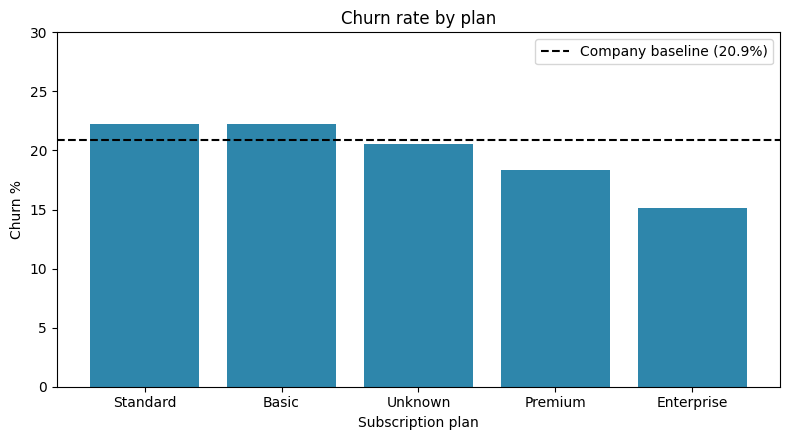

In [30]:
# ----------------------------------------------------------------
# Chart: churn by plan
# ----------------------------------------------------------------
plan = segment(valid, "Subscription_Type")

plt.figure(figsize=(8,4.5))
plt.bar(plan.index.astype(str), plan["churn_rate"] * 100, color="#2E86AB")
plt.axhline(RATE * 100, color="black", linestyle="--", linewidth=1.5,
            label=f"Company baseline ({RATE*100:.1f}%)")
plt.ylim(0, 30)
plt.ylabel("Churn %")
plt.xlabel("Subscription plan")
plt.title("Churn rate by plan")
plt.legend()
plt.tight_layout()
plt.show()

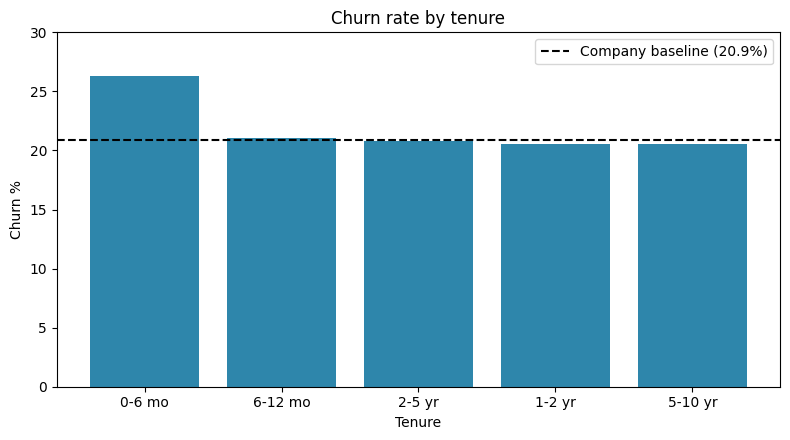

In [31]:
# ----------------------------------------------------------------
# Chart: churn by tenure
# ----------------------------------------------------------------
ten = segment(valid, "Tenure_Group")

plt.figure(figsize=(8, 4.5))
plt.bar(ten.index.astype(str), ten["churn_rate"] * 100, color="#2E86AB")
plt.axhline(RATE * 100, color="black", linestyle="--", linewidth=1.5,
            label=f"Company baseline ({RATE*100:.1f}%)")
plt.ylim(0, 30)
plt.ylabel("Churn %")
plt.xlabel("Tenure")
plt.title("Churn rate by tenure")
plt.legend()
plt.tight_layout()
plt.show()

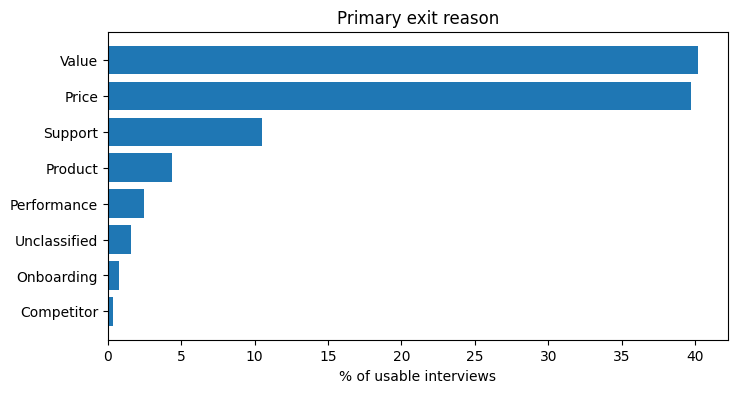

In [32]:
# ----------------------------------------------------------------
# Chart: primary exit reasons
# ----------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.barh(reason_tab.index[::-1], reason_tab["share"][::-1] * 100)
plt.xlabel("% of usable interviews")
plt.title("Primary exit reason")
plt.show()

In [33]:
# ----------------------------------------------------------------
# Retention targets and export clean files for Power BI
# ----------------------------------------------------------------

r1 = valid[(valid["Tenure_Months"] <= 6) & (valid["Support_Tickets"] >= 4)]
r2 = valid[valid["Subscription_Type"].isin(["Basic", "Standard"])]
r3 = valid[valid["Support_Tickets"] >= 4]

def rec(name, df):
    n = len(df)
    rate = df["Churn_Flag"].mean() if n else float("nan")
    lost = df.loc[df["Churn_Flag"] == 1, "Annual_Spend"].sum()
    print(f"{name:55s} n={n:7,}  churn={rate:5.1%}  churned ARR=₹{lost:,.0f}")

print(f"Baseline {RATE:.1%} on {N:,} accounts | churned ARR ₹{LOST:,.0f}")
rec("R1 first 6 months AND 4+ tickets", r1)
rec("R2 Basic + Standard plans", r2)
rec("R3 4+ support tickets", r3)

print("""
Put on slides:
1. Rescue 0–6 month accounts with 4+ tickets (onboarding + 48h reply SLA).
2. Split Price vs Value. Do not blanket-discount; prove ROI for Value comments.
3. Weekly save list for accounts with 4+ tickets.
""")

cust.to_csv(OUT / "customers_clean.csv", index=False)

interview_cols = [
    "Customer_ID",
    "Churn_Flag",
    "text",
    "usable",
    "primary_reason",
    "mood",
    "flag_Price",
    "flag_Value",
    "flag_Support",
    "flag_Product",
    "flag_Performance",
    "flag_Onboarding",
    "flag_Competitor",
]
iv[interview_cols].to_csv(OUT / "interviews_classified.csv", index=False)

matrix.to_csv(OUT / "reason_mood_matrix.csv")
reason_tab.to_csv(OUT / "reason_distribution.csv")
segment(valid, "Subscription_Type").to_csv(OUT / "churn_by_plan.csv")
segment(valid, "Tenure_Group").to_csv(OUT / "churn_by_tenure.csv")
segment(valid, "Region").to_csv(OUT / "churn_by_region.csv")
print("Saved files in", OUT.resolve())

Baseline 20.9% on 94,419 accounts | churned ARR ₹8,513,545
R1 first 6 months AND 4+ tickets                        n=    144  churn=37.5%  churned ARR=₹22,014
R2 Basic + Standard plans                               n= 65,710  churn=22.2%  churned ARR=₹3,501,038
R3 4+ support tickets                                   n=  3,233  churn=29.7%  churned ARR=₹415,361

Put on slides:
1. Rescue 0–6 month accounts with 4+ tickets (onboarding + 48h reply SLA).
2. Split Price vs Value. Do not blanket-discount; prove ROI for Value comments.
3. Weekly save list for accounts with 4+ tickets.

Saved files in C:\Users\DELL\outputs
